# Data Cleanup

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()
df.shape
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [2]:
print(df.isnull().sum())
print("="*50)
print((df['TotalCharges'].str.strip() == '').sum())
print("="*50)
print(df['Churn'].value_counts())
print("="*50)
print(df['Churn'].value_counts(normalize=True))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
11
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
df[df['TotalCharges'].str.strip() == ''][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

float64
0


In [5]:
customer_ids = df['customerID']
df = df.drop(columns=['customerID'])

In [6]:
print(df.shape)
print(df.columns.tolist())

(7043, 20)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
print(df['Churn'].unique())
print(df['Churn'].dtype)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].dtype)
print(df['Churn'].value_counts())

['No' 'Yes']
object
int64
Churn
0    5174
1    1869
Name: count, dtype: int64


In [9]:
#To confirm if the columns have hidden inconsitencies
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, ':', df[col].unique())
    print()

gender : ['Female' 'Male']

Partner : ['Yes' 'No']

Dependents : ['No' 'Yes']

PhoneService : ['No' 'Yes']

MultipleLines : ['No phone service' 'No' 'Yes']

InternetService : ['DSL' 'Fiber optic' 'No']

OnlineSecurity : ['No' 'Yes' 'No internet service']

OnlineBackup : ['Yes' 'No' 'No internet service']

DeviceProtection : ['No' 'Yes' 'No internet service']

TechSupport : ['No' 'Yes' 'No internet service']

StreamingTV : ['No' 'Yes' 'No internet service']

StreamingMovies : ['No' 'Yes' 'No internet service']

Contract : ['Month-to-month' 'One year' 'Two year']

PaperlessBilling : ['Yes' 'No']

PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']



In [12]:
df.info()
print("="*80)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


# EDA

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('images', exist_ok=True)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


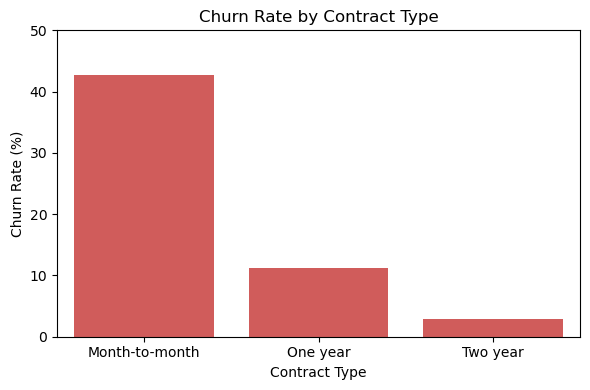

In [39]:
#Does churn rate differ by contract type?

churn_by_contract = (df.groupby('Contract')['Churn'].mean() * 100).sort_values(ascending=False)
print(churn_by_contract)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, color='#e34948')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('images/churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

**Finding — Contract type:** Month-to-month customers churn at 42.7%, vs 11.3% for 
one-year and just 2.8% for two-year contracts — roughly a 15x gap between the 
extremes. This looks like one of the strongest predictors in the dataset.

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


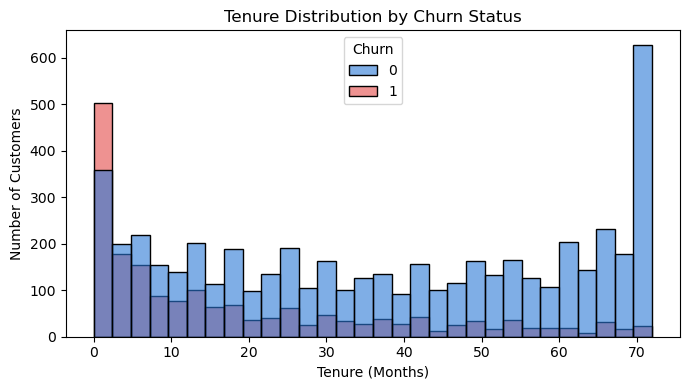

In [19]:
#Distribution of Tenure by Churn Status
tenure_by_churn = df.groupby('Churn')['tenure'].describe()
print(tenure_by_churn)

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='layer', alpha=0.6, palette=['#2a78d6', '#e34948'])
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('images/tenure_by_churn.png', dpi=300, bbox_inches='tight')
pl

**Finding — Tenure:** Churned customers have a median tenure of just 10 months, vs 
38 months for retained customers. Most churn happens early in the customer 
lifecycle, and this likely overlaps with the Contract finding above (new customers 
are more likely to be on flexible, month-to-month plans).

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


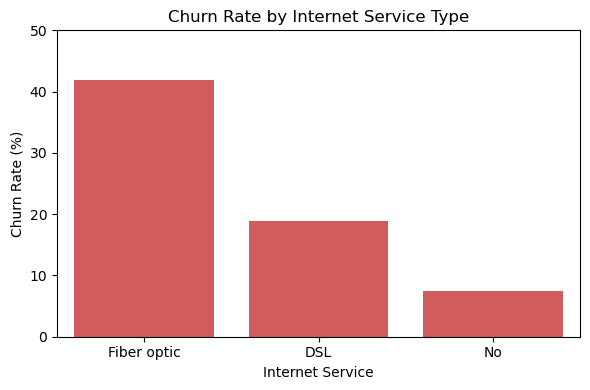

In [21]:
#Churn Rate by Internet Service Type
churn_by_internet = (df.groupby('InternetService')['Churn'].mean() * 100).sort_values(ascending=False)
print(churn_by_internet)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values, color='#e34948')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('images/churn_by_internet.png', dpi=300, bbox_inches='tight')
plt.show()

**Finding — Internet service:** Fiber optic customers churn at 41.9%, more than 
double DSL (19.0%) and nearly 6x customers with no internet (7.4%). Fiber is also 
the most expensive service (~$91.50/month avg vs $58.10 DSL, $21.08 none) — churn 
rate rises in step with price across all three groups.

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
0      5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1      1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


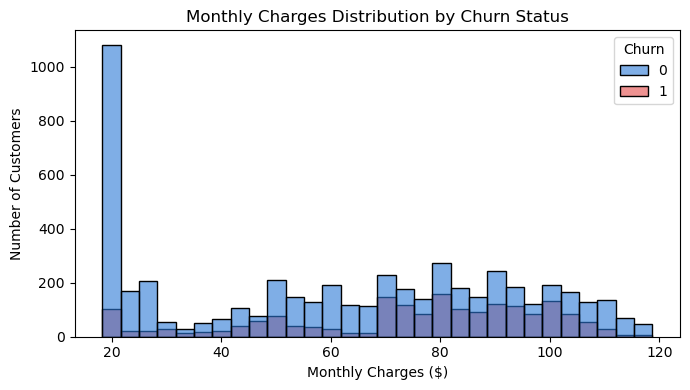

In [23]:
#Distribution of Monthly charge by Churn Status
charges_by_churn = df.groupby('Churn')['MonthlyCharges'].describe()
print(charges_by_churn)

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, multiple='layer', alpha=0.6, palette=['#2a78d6', '#e34948'])
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('images/monthlycharges_by_churn.png', dpi=300, bbox_inches='tight')
plt.show()

**Finding — Monthly charges:** Churned customers pay $74.44/month on average vs 
$61.27 for retained customers — roughly a $13 gap in both mean and median. Supports 
the cost-sensitivity story seen in the InternetService breakdown.

In [24]:
#Charges by Internet Use
charges_by_internet = df.groupby('InternetService')['MonthlyCharges'].mean().sort_values(ascending=False)
print(charges_by_internet)

InternetService
Fiber optic    91.500129
DSL            58.102169
No             21.079194
Name: MonthlyCharges, dtype: float64


In [26]:
#Churn Rate for Add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in addon_cols:
    print(col)
    print((df.groupby(col)['Churn'].mean() * 100).sort_values(ascending=False))
    print()

OnlineSecurity
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     39.127625
Yes                    22.502064
No internet service     7.404980
Name: Churn, dtype: float64

TechSupport
TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64

StreamingTV
StreamingTV
No                     33.523132
Yes                    30.070188
No internet service     7.404980
Name: Churn, dtype: float64

StreamingMovies
StreamingMovies
No                     33.680431
Yes                    29.941435
No internet service     7.404980
Name: Churn, dtype: float64



                         No        Yes
OnlineSecurity    41.766724  14.611194
OnlineBackup      39.928756  21.531494
DeviceProtection  39.127625  22.502064
TechSupport       41.635474  15.166341
StreamingTV       33.523132  30.070188
StreamingMovies   33.680431  29.941435


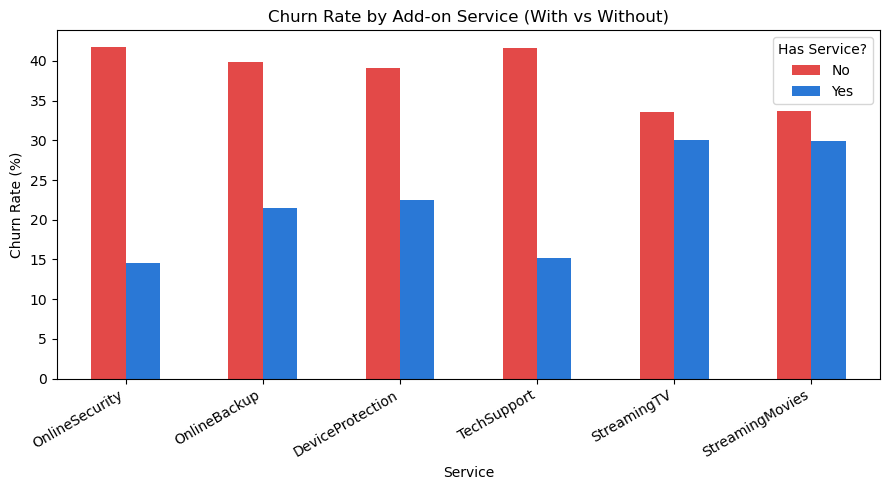

In [28]:
addon_summary = pd.DataFrame({
    col: df[df[col].isin(['Yes', 'No'])].groupby(col)['Churn'].mean() * 100
    for col in addon_cols
}).T

print(addon_summary)

plt.figure(figsize=(9, 5))
addon_summary[['No', 'Yes']].plot(kind='bar', color=['#e34948', '#2a78d6'], ax=plt.gca())
plt.title('Churn Rate by Add-on Service (With vs Without)')
plt.xlabel('Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Has Service?')
plt.tight_layout()
plt.savefig('images/churn_by_addons.png', dpi=300, bbox_inches='tight')
plt.show()

**Finding — Add-on services:** Customers without OnlineSecurity, TechSupport, 
OnlineBackup, or DeviceProtection churn 17–27 percentage points more than customers 
with them. StreamingTV and StreamingMovies show almost no gap (~3 points) — these 
look like "nice to have" services rather than retention drivers.

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


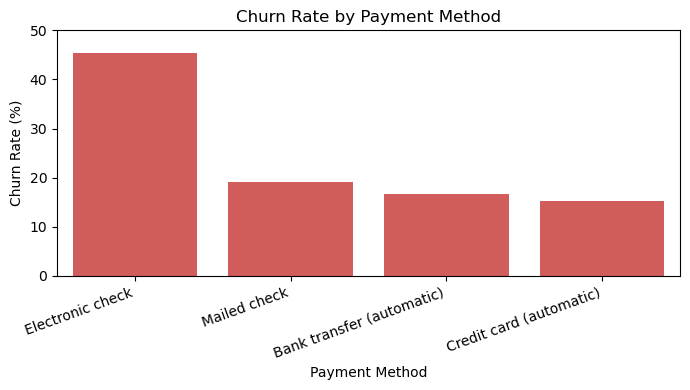

In [30]:
#Churn Rate by Payment Method
churn_by_payment = (df.groupby('PaymentMethod')['Churn'].mean() * 100).sort_values(ascending=False)
print(churn_by_payment)

plt.figure(figsize=(7, 4))
sns.barplot(x=churn_by_payment.index, y=churn_by_payment.values, color='#e34948')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('images/churn_by_payment.png', dpi=300, bbox_inches='tight')
plt.show()

**Finding — Payment method:** Electronic check users churn at 45.3% — more than 
double any other payment method (15.2–19.1%). This is the only manual, recurring 
payment method in the group; automatic methods show consistently lower churn.

                  tenure  MonthlyCharges  TotalCharges  SeniorCitizen  \
tenure          1.000000        0.247900      0.826178       0.016567   
MonthlyCharges  0.247900        1.000000      0.651174       0.220173   
TotalCharges    0.826178        0.651174      1.000000       0.103006   
SeniorCitizen   0.016567        0.220173      0.103006       1.000000   
Churn          -0.352229        0.193356     -0.198324       0.150889   

                   Churn  
tenure         -0.352229  
MonthlyCharges  0.193356  
TotalCharges   -0.198324  
SeniorCitizen   0.150889  
Churn           1.000000  


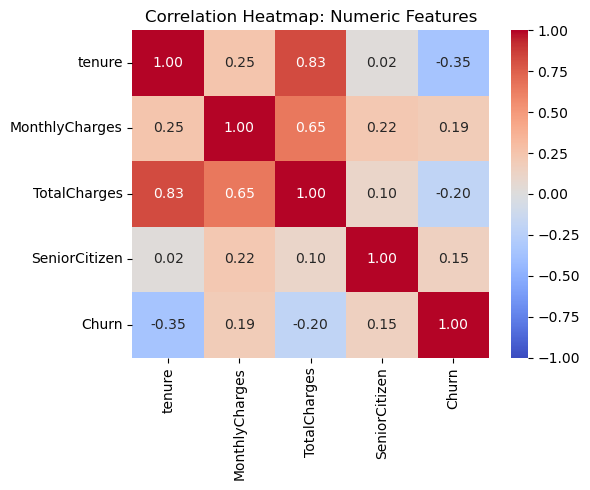

In [31]:
#Correlation Check

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Numeric Features')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Finding — Numeric correlations:** Tenure has the strongest correlation with churn 
(r = -0.35), followed by TotalCharges (r = -0.20) and MonthlyCharges (r = +0.19). 
Tenure and TotalCharges are themselves strongly correlated (r = 0.83), as expected — 
longer-tenured customers naturally accumulate higher total billing.

In [36]:
#Correlation between contract and payment method
from scipy.stats import chi2_contingency

crosstab = pd.crosstab(df['PaymentMethod'], df['Contract'], normalize='index') * 100
print(crosstab.round(1))

chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(df['PaymentMethod'], df['Contract']))
print(f"\nChi-square p-value: {p_value:.10f}")

Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)            38.1      25.3      36.5
Credit card (automatic)              35.7      26.1      38.2
Electronic check                     78.2      14.7       7.1
Mailed check                         55.4      20.9      23.7

Chi-square p-value: 0.0000000000


In [37]:
#Correlation between Internet Services and Contract

crosstab_internet_contract = pd.crosstab(df['InternetService'], df['Contract'], normalize='index') * 100
print(crosstab_internet_contract.round(1))

chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(df['InternetService'], df['Contract']))
print(f"\nChi-square p-value: {p_value:.10f}")

Contract         Month-to-month  One year  Two year
InternetService                                    
DSL                        50.5      23.5      25.9
Fiber optic                68.7      17.4      13.9
No                         34.3      23.9      41.8

Chi-square p-value: 0.0000000000


**Finding — Overlapping features:** Chi-square tests confirm PaymentMethod and 
InternetService are not independent of Contract (both p ≈ 0). 78.2% of Electronic 
check users are month-to-month, and 68.7% of Fiber optic customers are month-to-month 
— vs 35–55% and 34–50% respectively for other groups. This means part of what looked 
like separate effects is really the same Contract/tenure pattern showing up again 
under different features.

## EDA Summary

Contract type and tenure appear to be the backbone of churn risk in this dataset, 
with pricing, payment method, and internet service type layered on top and echoing 
the same underlying pattern to varying degrees.

**Working profile of a high-risk customer:** new, month-to-month, fiber optic 
internet, paying by electronic check, without security/support add-ons, paying a 
premium monthly price.

These are associations found through exploratory analysis, not proof of causation — 
confirming which features carry independent predictive value is a question for the 
modeling phase.

# Variance Inflation Factor (VIF)

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

df_vif = pd.get_dummies(df, drop_first=True)
df_vif = df_vif.astype(float)

df_vif_const = sm.add_constant(df_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = df_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(df_vif_const.values, i) for i in range(df_vif_const.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                              Feature        VIF
   OnlineSecurity_No internet service        inf
       MultipleLines_No phone service        inf
                     PhoneService_Yes        inf
                   InternetService_No        inf
      StreamingTV_No internet service        inf
 DeviceProtection_No internet service        inf
     OnlineBackup_No internet service        inf
      TechSupport_No internet service        inf
  StreamingMovies_No internet service        inf
                       MonthlyCharges 865.073910
          InternetService_Fiber optic 148.342004
                  StreamingMovies_Yes  24.117761
                      StreamingTV_Yes  24.063662
                         TotalCharges  10.866309
                               tenure   7.542762
                    MultipleLines_Yes   7.279811
                 DeviceProtection_Yes   6.922464
                     OnlineBackup_Yes   6.783091
                      TechSupport_Yes   6.470730
                   O

In [43]:
cols_to_collapse = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_collapse:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

for col in cols_to_collapse:
    print(col, ':', df[col].unique())

MultipleLines : ['No' 'Yes']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']


In [44]:
df_vif = pd.get_dummies(df, drop_first=True)
df_vif = df_vif.astype(float)

df_vif_const = sm.add_constant(df_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = df_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(df_vif_const.values, i) for i in range(df_vif_const.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

                              Feature        VIF
                       MonthlyCharges 865.073910
          InternetService_Fiber optic 148.342004
                   InternetService_No 104.256994
                     PhoneService_Yes  34.861577
                  StreamingMovies_Yes  24.117761
                      StreamingTV_Yes  24.063662
                         TotalCharges  10.866309
                               tenure   7.542762
                    MultipleLines_Yes   7.279811
                 DeviceProtection_Yes   6.922464
                     OnlineBackup_Yes   6.783091
                      TechSupport_Yes   6.470730
                   OnlineSecurity_Yes   6.338920
                    Contract_Two year   2.639233
       PaymentMethod_Electronic check   1.983505
           PaymentMethod_Mailed check   1.860579
                    Contract_One year   1.635573
PaymentMethod_Credit card (automatic)   1.560766
                          Partner_Yes   1.462703
                    

## Multicollinearity Check (VIF)

We used Variance Inflation Factor (VIF) to check whether any features overlap so 
much with each other that they're not really adding new information — a numeric, 
more rigorous version of the overlap patterns we noticed earlier in EDA 
(e.g. Contract vs PaymentMethod).

**First run** revealed several features with infinite VIF — meaning they could be 
predicted with 100% certainty from other columns. This confirmed a real structural 
issue: the "No internet service" / "No phone service" categories in seven columns 
(MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, 
StreamingTV, StreamingMovies) were exact duplicates of information already captured 
by InternetService and PhoneService. These were collapsed into a simple Yes/No.

**Second run**, after the fix, showed no more infinite values. A few features 
remained high — MonthlyCharges (865), InternetService_Fiber optic (148), 
InternetService_No (104), and PhoneService_Yes (35) — because MonthlyCharges is 
essentially a calculated total of which services a customer has, so it naturally 
overlaps heavily with those service columns. This is a softer, expected kind of 
overlap, not a data error.

**Decision:** Rather than dropping features to force lower VIF scores, we're 
keeping all features going into modeling. We'll compare a linear model 
(Logistic Regression) against a tree-based model (Random Forest), as we did in 
earlier projects. Tree-based models naturally handle overlapping features well, 
so this isn't a blocker for them. For Logistic Regression, we'll stay cautious 
when interpreting individual coefficients, since correlated features can make 
those numbers unstable or misleading even when the model's predictions are fine.


# Encoding

In [45]:
# Binary encode the two-option columns

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    print(col, ':', df[col].unique())

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
PaperlessBilling : ['Yes' 'No']
MultipleLines : ['No' 'Yes']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']


In [46]:
# Converting each Yes/No and (Male/Female) column into 1/0

df['gender'] = df['gender'].map({'Male':1, 'Female': 0})

yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(df[['gender'] + yes_no_cols].dtypes)
print()
print(df[['gender'] + yes_no_cols].head())

gender              int64
Partner             int64
Dependents          int64
PhoneService        int64
PaperlessBilling    int64
MultipleLines       int64
OnlineSecurity      int64
OnlineBackup        int64
DeviceProtection    int64
TechSupport         int64
StreamingTV         int64
StreamingMovies     int64
dtype: object

   gender  Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0       0        1           0             0                 1              0   
1       1        0           0             1                 0              0   
2       1        0           0             1                 1              0   
3       1        0           0             0                 0              0   
4       0        0           0             1                 1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1           

In [47]:
# One-hot encode the multi-option columns

multi_cols = ['Contract', 'InternetService', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

new_cols = [col for col in df.columns if any(col.startswith(m) for m in multi_cols)]
print(new_cols)
print()
print(df[new_cols].dtypes)

['Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Contract_One year                        bool
Contract_Two year                        bool
InternetService_Fiber optic              bool
InternetService_No                       bool
PaymentMethod_Credit card (automatic)    bool
PaymentMethod_Electronic check           bool
PaymentMethod_Mailed check               bool
dtype: object


In [48]:
df[new_cols] =df[new_cols].astype(int)

print(df[new_cols].dtypes)

Contract_One year                        int64
Contract_Two year                        int64
InternetService_Fiber optic              int64
InternetService_No                       int64
PaymentMethod_Credit card (automatic)    int64
PaymentMethod_Electronic check           int64
PaymentMethod_Mailed check               int64
dtype: object


In [49]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,1,0,0,1,0


## Encoding

Converted every remaining text column into numbers, using two different methods 
depending on the column type:

**Binary columns (12 total)** — gender, Partner, Dependents, PhoneService, 
PaperlessBilling, and the 7 service columns (MultipleLines, OnlineSecurity, 
OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) — 
mapped directly to 1/0, since there's no meaningful order between two options.

**Multi-option columns (3 total)** — Contract, InternetService, PaymentMethod — 
one-hot encoded instead of simple numbering, since assigning 0/1/2 would falsely 
imply an order or scale between categories that doesn't actually exist (e.g. 
"Two year" is not mathematically "twice" anything). Each option became its own 
Yes/No column, with one category per feature dropped (drop_first=True) as the 
implied default, to avoid redundancy.

**Result:** All 24 columns are now numeric (int64/float64), no text columns 
remain, and the dataset is ready for train/test splitting.

# Train/Test Split

In [52]:
# Split the data into training and testing sets, keeping the same
# 73.5/26.5 churn ratio in both sets (stratified split), so we get a fair,
# representative test later rather than a lucky or unlucky random split.

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print()
print("Churn rate in training set:", y_train.mean().round(4))
print("Churn rate in test set:", y_test.mean().round(4))

Training set shape: (5634, 23)
Test set shape: (1409, 23)

Churn rate in training set: 0.2654
Churn rate in test set: 0.2654


## Train/Test Split

Split the data into 80% training / 20% testing (5,634 / 1,409 rows), using a 
stratified split to preserve the 73.5%/26.5% Churn ratio in both sets. Without 
stratifying, a random split could have produced training and test sets with 
noticeably different churn rates just by chance, making later evaluation harder 
to trust. Confirmed both sets landed at 0.2654 churn rate — matching the original 
dataset almost exactly.

A fixed random_state (42) was used so the split is reproducible — running this 
cell again will always produce the same split rather than a new random one each time.

# Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(X_train_scaled[cols_to_scale].describe())

             tenure  MonthlyCharges  TotalCharges
count  5.634000e+03    5.634000e+03  5.634000e+03
mean  -1.008935e-17   -2.402527e-16  2.522338e-17
std    1.000089e+00    1.000089e+00  1.000089e+00
min   -1.322329e+00   -1.544028e+00 -1.008922e+00
25%   -9.559779e-01   -9.711977e-01 -8.321009e-01
50%   -1.418632e-01    1.848336e-01 -3.968446e-01
75%    9.164859e-01    8.319124e-01  6.741944e-01
max    1.608483e+00    1.785939e+00  2.801869e+00


## Scaling

Scaled the three continuous numeric columns — tenure, MonthlyCharges, TotalCharges 
— using StandardScaler, which converts each value into "how many standard 
deviations above or below average" it is. This puts all three on a comparable 
scale, which matters for Logistic Regression (which weighs features together) but 
not for Random Forest (which splits on thresholds and is scale-invariant).

Binary and one-hot encoded columns were left as-is, since they're already 0/1 and 
scaling them further wouldn't change anything meaningful.

To avoid data leakage, the scaler was fit only on the training set, then applied 
(not re-fit) to the test set — mimicking a real deployment scenario where future 
data isn't available when the model is trained.

Confirmed: after scaling, all three columns have a mean of ~0 and standard 
deviation of 1 in the training set.

# Baseline models

### Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_log))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7402

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Confusion Matrix:
[[749 286]
 [ 80 294]]


### Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7949

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[938  97]
 [192 182]]


In [63]:
# feature importance

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

TotalCharges                      0.180124
tenure                            0.165103
MonthlyCharges                    0.164678
Contract_Two year                 0.058583
InternetService_Fiber optic       0.050545
PaymentMethod_Electronic check    0.041871
Contract_One year                 0.029940
PaperlessBilling                  0.027194
gender                            0.026366
OnlineSecurity                    0.024610
dtype: float64


## Baseline Models

Trained two baseline classifiers for comparison, both using class_weight='balanced' 
to address the 73.5/26.5 churn imbalance:

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 74.0% | 79.5% |
| Churn (1) precision | 0.51 | 0.65 |
| Churn (1) recall | 0.79 | 0.49 |
| Churn (1) F1 | 0.62 | 0.56 |

**Trade-off:** Logistic Regression catches far more actual churners (79% recall) 
but with more false alarms (51% precision). Random Forest is more conservative — 
higher accuracy and precision, but misses over half of actual churners (49% 
recall). Neither model is objectively "better" without knowing the real-world cost 
of a missed churner vs. a false alarm.

**Feature importance (Random Forest)** confirmed the EDA findings almost exactly: 
TotalCharges, tenure, and MonthlyCharges together account for ~51% of the model's 
decisions, followed by Contract, InternetService, and PaymentMethod — the same 
features and rough ordering identified manually during EDA.

**Next steps:** hyperparameter tuning, and/or testing a probability threshold 
other than the default 0.5 to shift the precision/recall balance toward whichever 
matters more for the business use case.

# Threshold tuning

In [64]:
# How do precision and recall change as we move the decision threshold
# away from the default 0.5, using Logistic Regression's predicted probabilities?

from sklearn.metrics import precision_score, recall_score, f1_score

y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for t in thresholds:
    y_pred_t = (y_proba_log >= t).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold {t}: Precision={precision:.3f} Recall={recall:.3f} F1={f1:.3f}")
    

Threshold 0.3: Precision=0.432 Recall=0.928 F1=0.589
Threshold 0.35: Precision=0.447 Recall=0.904 F1=0.598
Threshold 0.4: Precision=0.466 Recall=0.866 F1=0.606
Threshold 0.45: Precision=0.482 Recall=0.837 F1=0.612
Threshold 0.5: Precision=0.507 Recall=0.786 F1=0.616
Threshold 0.55: Precision=0.526 Recall=0.751 F1=0.619
Threshold 0.6: Precision=0.540 Recall=0.703 F1=0.611


# Gradient Boosting Model

In [66]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_gb), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_gb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.7984

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[935 100]
 [184 190]]


In [67]:
# Does explicitly weighting the minority class improve Gradient
# Boosting's recall, the way class_weight='balanced' helped Logistic Regression?

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_weighted = GradientBoostingClassifier(random_state=42)
gb_weighted.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb_w = gb_weighted.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_gb_w), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_gb_w))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb_w))

Accuracy: 0.7431

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Confusion Matrix:
[[749 286]
 [ 76 298]]


# Hyperparameter tuning - Random Forest, optimized for recall

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated recall:", round(grid_search.best_score_, 4))

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated recall: 0.7973


In [70]:
# Evaluating the tuned model on the test set

best_rf = grid_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf_tuned), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Accuracy: 0.7559

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409


Confusion Matrix:
[[764 271]
 [ 73 301]]


## Hyperparameter Tuning

Used GridSearchCV (5-fold cross-validation, 108 combinations tested) to tune 
Random Forest, optimizing for recall on the churn class per the business 
reasoning that missed churners are costlier than false alarms.

Best parameters: max_depth=5, min_samples_leaf=1, min_samples_split=10, 
n_estimators=100.

Result on test set: 75.6% accuracy, 0.53 precision / 0.80 recall / 0.64 F1 for 
churn — the best result across all models tried so far, matching the top recall 
seen (0.80) while improving precision and accuracy over both Logistic Regression 
and weighted Gradient Boosting. Confirms that a shallower, less overfit tree, 
combined with class balancing, generalizes better than an unconstrained tree.

# Feature Engineering

In [74]:
# Create new engineered features based on EDA findings, to see if
# they reveal information the raw columns don't expose on their own.

# Average monthly spend = TotalCharges / tenure
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure']
df['AvgMonthlySpend'] = df['AvgMonthlySpend'].fillna(df['MonthlyCharges'])

# Total number of add-on services subscribed (sum of the 7 Yes/No Service columns)
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = df[service_cols].sum(axis=1)

# Tenure grouped into life stages
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1, 12, 48, 100],
                           labels=['New (0-12mo)', 'Established (13-48mo)', 'Long-term (49mo+)'])

print(df[['tenure', 'TotalCharges', 'MonthlyCharges', 'AvgMonthlySpend', 'TotalServices', 'TenureGroup']].head(10))

   tenure  TotalCharges  MonthlyCharges  AvgMonthlySpend  TotalServices  \
0       1         29.85           29.85        29.850000              1   
1      34       1889.50           56.95        55.573529              2   
2       2        108.15           53.85        54.075000              2   
3      45       1840.75           42.30        40.905556              3   
4       2        151.65           70.70        75.825000              0   
5       8        820.50           99.65       102.562500              4   
6      22       1949.40           89.10        88.609091              3   
7      10        301.90           29.75        30.190000              1   
8      28       3046.05          104.80       108.787500              5   
9      62       3487.95           56.15        56.257258              2   

             TenureGroup  
0           New (0-12mo)  
1  Established (13-48mo)  
2           New (0-12mo)  
3  Established (13-48mo)  
4           New (0-12mo)  
5           

In [75]:
# Encode TenureGroup and rebuild the modeling dataset

df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

new_tenure_cols = [col for col in df.columns if col.startswith('TenureGroup')]
df[new_tenure_cols] = df[new_tenure_cols].astype(int)
print(df[new_tenure_cols].dtypes)
print()
print(df.info())

TenureGroup_Established (13-48mo)    int64
TenureGroup_Long-term (49mo+)        int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       

In [77]:
# Rebuilding the train/test split and scaling with the new features

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5634, 27)
Test set shape: (1409, 27)


In [78]:
# Retraining our best model so far (tuned Random Forest) with the new features

rf_engineered = RandomForestClassifier(
    max_depth=5, min_samples_leaf=1, min_samples_split=10,
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_engineered.fit(X_train, y_train)

y_pred_eng = rf_engineered.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_eng), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_eng))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_eng))

Accuracy: 0.7488

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Confusion Matrix:
[[751 284]
 [ 70 304]]


In [79]:
# Logistic Regression with TenureGroup

log_reg_eng = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_eng.fit(X_train_scaled, y_train)

y_pred_log_eng = log_reg_eng.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_log_eng), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_log_eng))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_eng))

Accuracy: 0.7331

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409


Confusion Matrix:
[[737 298]
 [ 78 296]]


## Feature Engineering

Created three new features based on EDA reasoning: AvgMonthlySpend 
(TotalCharges/tenure), TotalServices (count of the 7 add-on services subscribed), 
and TenureGroup (tenure bucketed into New/Established/Long-term).

**Result: none of the three features improved model performance.** Tested against 
both tuned Random Forest and Logistic Regression — results were flat to very 
slightly worse across the board in both cases.

**Why this likely happened:** AvgMonthlySpend is a direct ratio of two features 
the models already had, and tree-based models can approximate such combinations 
on their own. TotalServices condensed 7 individually meaningful columns into one 
number, likely losing the distinction (found in EDA) that security/support 
services matter more to churn than entertainment services. TenureGroup, tested 
specifically on Logistic Regression on the hypothesis that it couldn't discover 
tenure thresholds on its own, also showed no improvement — the raw continuous 
tenure value already carried the same information more precisely.

**Conclusion:** the best-performing model remains tuned Random Forest using only 
the original cleaned and encoded features (75.6% accuracy, 0.53 precision, 
0.80 recall, 0.64 F1 on the churn class). Feature engineering can genuinely 
improve a model, but only when it adds information the model couldn't already 
infer — here, the engineered features were largely redundant rather than novel.